[INFO] Using device: cuda
[INFO] Loaded buffer from: metamotivo-S-1-datasets/data/buffer_inference_500000.hdf5
[INFO] Loaded FB-CPR model from HuggingFace.
[INFO] Constructed RewardWrapper for reward-based task inference.
[INFO] Computing backward embeddings for 100000 dataset states.
[INFO] B_dataset shape: (100000, 256)
[INFO] Starting rollouts for task 'raisearms-h-l'.


  0%|          | 0/30 [00:00<?, ?it/s]

[INFO] Task 'raisearms-h-l': collected 9000 states over 30 episodes. Mean return = 43.94
[INFO] Dataset self-NN distances: mean=1.1414, median=1.1897
[INFO] Task 'raisearms-h-l': NN distances mean=1.1068, median=1.1005
[INFO] Dataset 95th percentile NN distance: 1.2655
[INFO] Saved NN histogram figure to: fb_humenv_nn_histograms.png
[INFO] Saved PCA scatter figure to: fb_humenv_pca_occupancies.png

[RESULTS] Episode returns (mean ± std):
  raisearms-h-l       :    43.94 ±   1.26


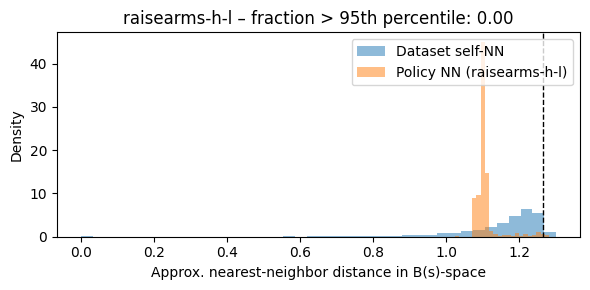

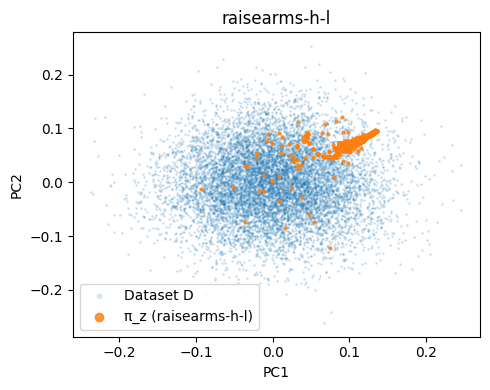

In [ ]:
import os
import sys
sys.path.append("../")
os.environ['MUJOCO_GL']='egl'

import dotenv
dotenv.load_dotenv()

import os
os.environ["OMP_NUM_THREADS"] = "1"

import h5py
import math
import numpy as np
import torch
import matplotlib.pyplot as plt

from huggingface_hub import hf_hub_download

from metamotivo.fb_cpr.huggingface import FBcprModel
from metamotivo.buffers.buffers import DictBuffer
from metamotivo.wrappers.humenvbench import RewardWrapper
from tqdm.auto import tqdm
from humenv import make_humenv
import gymnasium

MODEL_ID = "facebook/metamotivo-S-1"
DATASET_FILENAME = "buffer_inference_500000.hdf5"
LOCAL_DATA_DIR = "metamotivo-S-1-datasets"

# Number of dataset observations for B(s) reference
NUM_DATASET_SAMPLES_FOR_EMBEDDINGS = 200_000

# Number of B(s) samples from each policy to use in analysis
MAX_POLICY_STATES_PER_TASK = 20_000

# Nearest-neighbor approximation parameters
DATASET_BASELINE_QUERY = 5_000   # dataset self-NN baseline
POLICY_QUERY_PER_TASK = 5_000    # NN distances for each task
NN_CANDIDATES = 512              # candidate neighbors from dataset for approximate NN
NN_BATCH_SIZE = 1024

# Evaluation rollout parameters
NUM_EPISODES_PER_TASK = 30
MAX_EPISODE_STEPS = 300 # from paper

# Tasks to test – these are HumEnv benchmark tasks used in Meta Motivo / ZOL
TASKS = [
    "raisearms-h-l"
    # "rotate-x-5-0.8",
    # "crouch-0"
    # "move-ego-0-0",   # locomotion forward
    # "headstand",      # fairly uncommon configuration
    # "sitonground",    # seated pose
]

RANDOM_SEED = 0

def set_seed(seed: int) -> None:
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


def load_buffer(model_id: str,
                dataset_filename: str,
                local_dir: str,
                device: torch.device):
    """
    Download the Meta Motivo inference buffer from HuggingFace and construct
    a DictBuffer compatible with MetaMotivo's RewardWrapper.

    Returns:
        buffer: DictBuffer
        observations: np.ndarray, shape [N, obs_dim]
    """
    buffer_path = hf_hub_download(
        repo_id=model_id,
        filename=f"data/{dataset_filename}",
        repo_type="model",
        local_dir=local_dir,
    )
    print(f"[INFO] Loaded buffer from: {buffer_path}")

    hf = h5py.File(buffer_path, "r")
    data = {k: v[:] for k, v in hf.items()}
    hf.close()

    # DictBuffer is what RewardWrapper expects
    if "qpos" not in data:
        raise KeyError(
            f"'qpos' not found in buffer. Available keys: {list(data.keys())}"
        )
    buffer = DictBuffer(capacity=data["qpos"].shape[0], device="cpu")
    buffer.extend(data)

    if "observation" not in data:
        raise KeyError(
            f"'observation' not found in buffer. Available keys: {list(data.keys())}"
        )
    observations = data["observation"]  # np.ndarray shape [N, obs_dim]

    return buffer, observations


def build_models(device: torch.device, buffer: DictBuffer):
    """
    Load FB-CPR model and wrap it with RewardWrapper for reward-based inference.

    Returns:
        base_model: FBcprModel
        reward_model: RewardWrapper
    """
    base_model = FBcprModel.from_pretrained(MODEL_ID)
    base_model.to(device)
    base_model.eval()
    print("[INFO] Loaded FB-CPR model from HuggingFace.")

    reward_model = RewardWrapper(
        model=base_model,
        inference_dataset=buffer,
        num_samples_per_inference=100_000,
        inference_function="reward_wr_inference",
        max_workers=8,
    )
    print("[INFO] Constructed RewardWrapper for reward-based task inference.")

    return base_model, reward_model


def sample_backward_embeddings(base_model: FBcprModel,
                               observations: np.ndarray,
                               num_samples: int,
                               device: torch.device,
                               batch_size: int = 4096,
                               seed: int = 0):
    """
    Sample random observations from the buffer and compute their backward embeddings B(s).

    Returns:
        B_dataset: np.ndarray, shape [num_samples, d]
    """
    rng = np.random.default_rng(seed)
    N = observations.shape[0]
    num_samples = min(num_samples, N)
    idx = rng.choice(N, size=num_samples, replace=False)
    obs_samples = observations[idx]

    print(f"[INFO] Computing backward embeddings for {num_samples} dataset states.")
    all_embeddings = []

    base_model.eval()
    with torch.no_grad():
        for start in range(0, num_samples, batch_size):
            end = min(start + batch_size, num_samples)
            batch = obs_samples[start:end]
            obs_t = torch.from_numpy(batch).to(device=device, dtype=torch.float32)
            emb = base_model.backward_map(obs_t)  # [B, d]
            emb = torch.nn.functional.normalize(emb, dim=-1)
            all_embeddings.append(emb.cpu())

    B = torch.cat(all_embeddings, dim=0)  # [num_samples, d]
    return B.numpy()


def rollout_task(reward_model: RewardWrapper,
                 base_model: FBcprModel,
                 task_name: str,
                 device: torch.device,
                 num_episodes: int,
                 max_episode_steps: int,
                 max_states_for_analysis: int):
    """
    Roll out the reward-based policy pi_z for a given HumEnv task and collect
    backward embeddings B(s) for visited states.

    Returns:
        B_policy: np.ndarray, shape [N_policy_states, d]
        episode_returns: np.ndarray, shape [num_episodes]
    """
    print(f"[INFO] Starting rollouts for task '{task_name}'.")

    # Infer latent z for this task using RewardWrapper's reward inference
    z = reward_model.reward_inference(task_name)
    if isinstance(z, np.ndarray):
        z_t = torch.from_numpy(z).to(device=device, dtype=torch.float32)
    else:
        z_t = z.to(device)
    if z_t.ndim == 1:
        z_t = z_t.unsqueeze(0)  # [1, d]

    env, _ = make_humenv(
        num_envs=1,
        task=task_name,
        state_init="DefaultAndFall",
        wrappers=[gymnasium.wrappers.FlattenObservation],
    )

    all_B = []
    episode_returns = []
    total_states_collected = 0

    base_model.eval()
    pbar = tqdm(range(num_episodes))
    for ep in pbar:
        obs_np, info = env.reset()
        done = False
        t = 0
        ep_return = 0.0

        while (not done) and (t < max_episode_steps):
            obs_t = torch.from_numpy(obs_np.reshape(1, -1)).to(
                device=device, dtype=torch.float32
            )
            with torch.no_grad():
                # backward embedding of current state
                B_t = base_model.backward_map(obs_t)  # [1, d]
                B_t = torch.nn.functional.normalize(B_t, dim=-1)
                all_B.append(B_t.cpu().numpy())
                total_states_collected += 1

                # act with zero-shot reward policy
                action_t = reward_model.act(obs=obs_t, z=z_t, mean=True)  # [1, act_dim]
            obs_np, r, terminated, truncated, info = env.step(action_t)
            done = bool(terminated or truncated)
            ep_return += float(r)
            t += 1

            if total_states_collected >= max_states_for_analysis:
                break

        episode_returns.append(ep_return)
        if total_states_collected >= max_states_for_analysis:
            break

    env.close()
    B_policy = np.concatenate(all_B, axis=0)  # [N_policy_states, d]
    episode_returns = np.array(episode_returns, dtype=np.float32)

    print(
        f"[INFO] Task '{task_name}': collected {B_policy.shape[0]} states over "
        f"{len(episode_returns)} episodes. Mean return = {episode_returns.mean():.2f}"
    )

    return B_policy, episode_returns


def approximate_nn_distances(B_dataset: np.ndarray,
                             B_query: np.ndarray,
                             num_candidates: int = NN_CANDIDATES,
                             batch_size: int = NN_BATCH_SIZE,
                             seed: int = 0):
    """
    Approximate nearest-neighbor distances in B-space from query points to the dataset.

    We:
      * randomly choose `num_candidates` dataset points as candidate neighbors,
      * for each query batch, compute Euclidean distances to the candidate set,
      * take the minimum over candidates.

    This is not an exact k-NN, but more than sufficient to reveal support mismatch.
    """
    rng = np.random.default_rng(seed)
    N, d = B_dataset.shape
    M = B_query.shape[0]

    K = min(num_candidates, N)
    candidate_idx = rng.choice(N, size=K, replace=False)
    C = B_dataset[candidate_idx].astype(np.float32)  # [K, d]

    dists = np.empty(M, dtype=np.float32)

    for start in range(0, M, batch_size):
        end = min(start + batch_size, M)
        Q = B_query[start:end].astype(np.float32)  # [B, d]
        # Q: [B, d], C: [K, d] -> diff: [B, K, d]
        diff = Q[:, None, :] - C[None, :, :]
        dist_sq = np.sum(diff * diff, axis=-1)  # [B, K]
        dists[start:end] = np.sqrt(np.min(dist_sq, axis=1))

    return dists


def pca_projection(B_dataset: np.ndarray,
                   B_policies: dict,
                   max_dataset_points: int = 10_000,
                   max_policy_points: int = 2_000,
                   seed: int = 0):
    """
    Compute a 2D PCA of B_dataset and project both dataset and each policy's B(s)
    into that 2D space.

    Returns:
        proj_dataset: np.ndarray [N_ds_sub, 2]
        proj_policies: dict[str -> np.ndarray [N_pol_sub, 2]]
    """
    rng = np.random.default_rng(seed)
    N, d = B_dataset.shape
    N_ds_sub = min(max_dataset_points, N)
    idx_ds = rng.choice(N, size=N_ds_sub, replace=False)
    X_ds = torch.from_numpy(B_dataset[idx_ds]).float()  # [N_ds_sub, d]

    # Center the dataset
    mean = X_ds.mean(dim=0, keepdim=True)  # [1, d]
    X_centered = X_ds - mean

    # Low-rank PCA (Torch >= 2.0, MetaMotivo requires >= 2.3)
    U, S, V = torch.pca_lowrank(X_centered, q=2, center=False)  # V: [d, 2]
    V2 = V[:, :2]  # [d, 2]

    proj_dataset = (X_centered @ V2).cpu().numpy()  # [N_ds_sub, 2]

    proj_policies = {}
    for task_name, B_pol in B_policies.items():
        M = B_pol.shape[0]
        if M == 0:
            proj_policies[task_name] = np.zeros((0, 2), dtype=np.float32)
            continue
        M_sub = min(max_policy_points, M)
        idx_pol = rng.choice(M, size=M_sub, replace=False)
        X_pol = torch.from_numpy(B_pol[idx_pol]).float()  # [M_sub, d]
        X_pol_centered = X_pol - mean  # center with dataset mean
        proj_pol = (X_pol_centered @ V2).cpu().numpy()  # [M_sub, 2]
        proj_policies[task_name] = proj_pol

    return proj_dataset, proj_policies


def plot_nn_histograms(dataset_nn: np.ndarray,
                       policy_nns: dict,
                       save_path: str):
    """
    Plot histograms of approximate NN distances:
       - dataset self-NN baseline
       - each task's policy vs dataset
    """
    threshold_95 = np.quantile(dataset_nn, 0.95)
    print(f"[INFO] Dataset 95th percentile NN distance: {threshold_95:.4f}")

    num_tasks = len(policy_nns)
    fig, axes = plt.subplots(
        num_tasks, 1, figsize=(6, 3 * num_tasks), sharex=True
    )

    if num_tasks == 1:
        axes = [axes]

    for ax, (task, dists_pol) in zip(axes, policy_nns.items()):
        ax.hist(
            dataset_nn,
            bins=40,
            density=True,
            alpha=0.5,
            label="Dataset self-NN",
        )
        ax.hist(
            dists_pol,
            bins=40,
            density=True,
            alpha=0.5,
            label=f"Policy NN ({task})",
        )
        frac_ood = float((dists_pol > threshold_95).mean())
        ax.axvline(threshold_95, color="k", linestyle="--", linewidth=1.0)
        ax.set_ylabel("Density")
        ax.set_title(
            f"{task} – fraction > 95th percentile: {frac_ood:.2f}"
        )
        ax.legend(loc="upper right")

    axes[-1].set_xlabel("Approx. nearest-neighbor distance in B(s)-space")

    fig.tight_layout()
    fig.savefig(save_path, dpi=300)
    print(f"[INFO] Saved NN histogram figure to: {save_path}")


def plot_pca_scatter(proj_dataset: np.ndarray,
                     proj_policies: dict,
                     save_path: str):
    """
    Plot 2D PCA of dataset backward embeddings and overlay policy occupancies
    for each task.
    """
    num_tasks = len(proj_policies)
    fig, axes = plt.subplots(
        1, num_tasks, figsize=(5 * num_tasks, 4), sharex=True, sharey=True
    )

    if num_tasks == 1:
        axes = [axes]

    for ax, (task, proj_pol) in zip(axes, proj_policies.items()):
        ax.scatter(
            proj_dataset[:, 0],
            proj_dataset[:, 1],
            s=1,
            alpha=0.15,
            label="Dataset D",
        )
        if proj_pol.shape[0] > 0:
            ax.scatter(
                proj_pol[:, 0],
                proj_pol[:, 1],
                s=4,
                alpha=0.8,
                label=f"π_z ({task})",
            )
        ax.set_title(task)
        ax.set_xlabel("PC1")
        ax.set_ylabel("PC2")
        ax.legend(loc="best", markerscale=3)

    fig.tight_layout()
    fig.savefig(save_path, dpi=300)
    print(f"[INFO] Saved PCA scatter figure to: {save_path}")

def main():
    set_seed(RANDOM_SEED)
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"[INFO] Using device: {device}")

    # 1) Load dataset buffer and observations
    buffer, observations = load_buffer(
        MODEL_ID, DATASET_FILENAME, LOCAL_DATA_DIR, device
    )

    # 2) Load FB-CPR and RewardWrapper
    base_model, reward_model = build_models(device, buffer)

    # 3) Compute backward embeddings for a large subset of dataset D
    B_dataset = sample_backward_embeddings(
        base_model=base_model,
        observations=observations,
        num_samples=NUM_DATASET_SAMPLES_FOR_EMBEDDINGS,
        device=device,
        seed=RANDOM_SEED,
    )
    print(f"[INFO] B_dataset shape: {B_dataset.shape}")

    # 4) Roll out policies for each task and collect B(s) for pi_z
    B_policies = {}
    returns_per_task = {}
    for task in TASKS:
        B_pol, ep_returns = rollout_task(
            reward_model=reward_model,
            base_model=base_model,
            task_name=task,
            device=device,
            num_episodes=NUM_EPISODES_PER_TASK,
            max_episode_steps=MAX_EPISODE_STEPS,
            max_states_for_analysis=MAX_POLICY_STATES_PER_TASK,
        )
        B_policies[task] = B_pol
        returns_per_task[task] = ep_returns

    # 5) Approximate NN distance baseline for dataset "self-NN"
    rng = np.random.default_rng(RANDOM_SEED)
    N_ds = B_dataset.shape[0]
    N_query_ds = min(DATASET_BASELINE_QUERY, N_ds)
    idx_query_ds = rng.choice(N_ds, size=N_query_ds, replace=False)
    B_query_ds = B_dataset[idx_query_ds]
    dataset_nn = approximate_nn_distances(
        B_dataset=B_dataset,
        B_query=B_query_ds,
        num_candidates=NN_CANDIDATES,
        batch_size=NN_BATCH_SIZE,
        seed=RANDOM_SEED,
    )
    print(
        f"[INFO] Dataset self-NN distances: mean={dataset_nn.mean():.4f}, "
        f"median={np.median(dataset_nn):.4f}"
    )

    # 6) Approximate NN distances for each policy's occupancy
    policy_nn_dists = {}
    for task, B_pol in B_policies.items():
        M = B_pol.shape[0]
        if M == 0:
            policy_nn_dists[task] = np.zeros(0, dtype=np.float32)
            continue
        N_query_pol = min(POLICY_QUERY_PER_TASK, M)
        idx_pol = rng.choice(M, size=N_query_pol, replace=False)
        B_query_pol = B_pol[idx_pol]
        dists_pol = approximate_nn_distances(
            B_dataset=B_dataset,
            B_query=B_query_pol,
            num_candidates=NN_CANDIDATES,
            batch_size=NN_BATCH_SIZE,
            seed=RANDOM_SEED + 1,
        )
        policy_nn_dists[task] = dists_pol
        print(
            f"[INFO] Task '{task}': NN distances mean={dists_pol.mean():.4f}, "
            f"median={np.median(dists_pol):.4f}"
        )

    # 7) Plot NN histograms
    plot_nn_histograms(
        dataset_nn=dataset_nn,
        policy_nns=policy_nn_dists,
        save_path="fb_humenv_nn_histograms.png",
    )

    # 8) PCA projection and scatter plots in B-space
    proj_dataset, proj_policies = pca_projection(
        B_dataset=B_dataset,
        B_policies=B_policies,
        seed=RANDOM_SEED,
    )
    plot_pca_scatter(
        proj_dataset=proj_dataset,
        proj_policies=proj_policies,
        save_path="fb_humenv_pca_occupancies.png",
    )

    # 9) Print returns per task for convenience
    print("\n[RESULTS] Episode returns (mean ± std):")
    for task, ep_returns in returns_per_task.items():
        mean_r = ep_returns.mean()
        std_r = ep_returns.std()
        print(f"  {task:20s}: {mean_r:8.2f} ± {std_r:6.2f}")


if __name__ == "__main__":
    main()


[INFO] Using device: cuda
[INFO] Loaded buffer from: metamotivo-S-1-datasets/data/buffer_inference_500000.hdf5
[INFO] Loaded FB-CPR model from HuggingFace.
[INFO] Constructed RewardWrapper for reward-based task inference.
[INFO] Computing backward embeddings for 200000 dataset states.
[INFO] B_dataset shape: (200000, 256)
[INFO] Starting rollouts for task 'rotate-x-5-0.8'.


  0%|          | 0/30 [00:00<?, ?it/s]

[INFO] Task 'rotate-x-5-0.8': collected 9000 states over 30 episodes. Mean return = 0.97
[INFO] Starting rollouts for task 'split-0.5'.


  0%|          | 0/30 [00:00<?, ?it/s]

[INFO] Task 'split-0.5': collected 9000 states over 30 episodes. Mean return = 253.60
[INFO] Dataset self-NN distances: mean=1.0917, median=1.1507
[INFO] Task 'rotate-x-5-0.8': NN distances mean=1.0509, median=1.0631
[INFO] Task 'split-0.5': NN distances mean=0.7350, median=0.7190
[INFO] Dataset 95th percentile NN distance: 1.2411
[INFO] Saved NN histogram figure to: fb_humenv_nn_histograms.png
[INFO] Saved PCA scatter figure to: fb_humenv_pca_occupancies.png

[RESULTS] Episode returns (mean ± std):
  rotate-x-5-0.8      :     0.97 ±   1.16
  split-0.5           :   253.60 ±   1.27


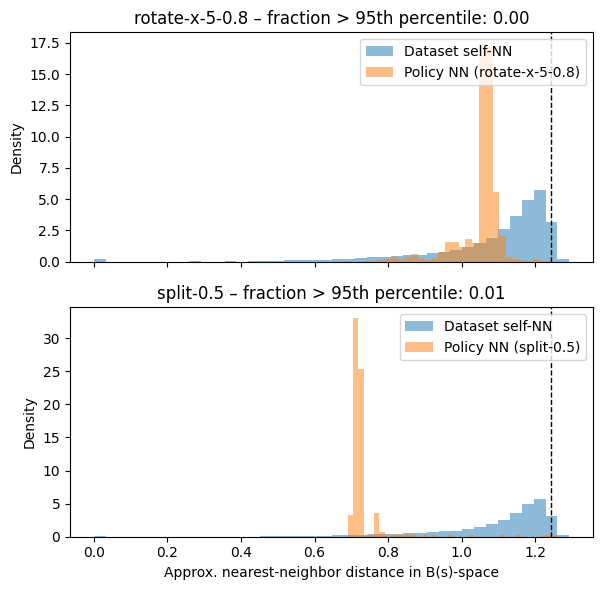

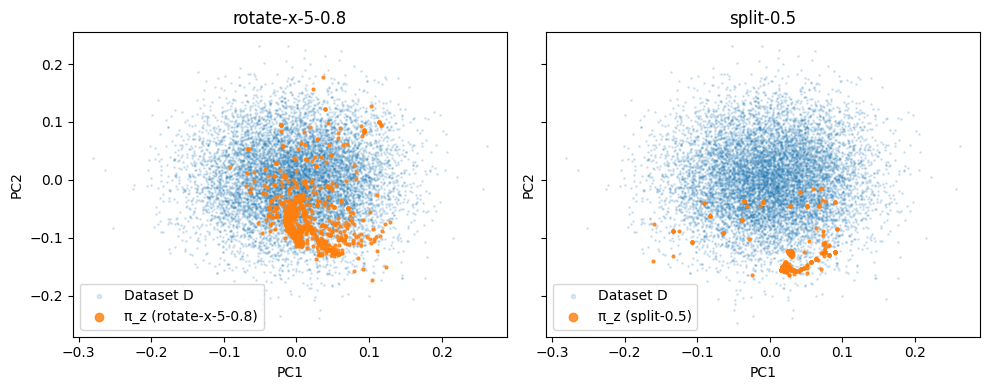

In [12]:
import os
import sys
sys.path.append("../")
os.environ['MUJOCO_GL']='egl'

import dotenv
dotenv.load_dotenv()

import os
os.environ["OMP_NUM_THREADS"] = "1"

import h5py
import math
import numpy as np
import torch
import matplotlib.pyplot as plt

from huggingface_hub import hf_hub_download

from metamotivo.fb_cpr.huggingface import FBcprModel
from metamotivo.buffers.buffers import DictBuffer
from metamotivo.wrappers.humenvbench import RewardWrapper
from tqdm.auto import tqdm
from humenv import make_humenv
import gymnasium

MODEL_ID = "facebook/metamotivo-S-1"
DATASET_FILENAME = "buffer_inference_500000.hdf5"
LOCAL_DATA_DIR = "metamotivo-S-1-datasets"

# Number of dataset observations for B(s) reference
NUM_DATASET_SAMPLES_FOR_EMBEDDINGS = 200_000

# Number of B(s) samples from each policy to use in analysis
MAX_POLICY_STATES_PER_TASK = 10_000

# Nearest-neighbor approximation parameters
DATASET_BASELINE_QUERY = 10_000   # dataset self-NN baseline
POLICY_QUERY_PER_TASK = 10_000    # NN distances for each task
NN_CANDIDATES = 1024              # candidate neighbors from dataset for approximate NN
NN_BATCH_SIZE = 1024

# Evaluation rollout parameters
NUM_EPISODES_PER_TASK = 30
MAX_EPISODE_STEPS = 300 # from paper

# Tasks to test – these are HumEnv benchmark tasks used in Meta Motivo / ZOL
TASKS = [
    # "raisearms-h-l"
    # "rotate-x-5-0.8",
    # "crouch-0"
    # "move-ego-0-0",   # locomotion forward
    # "headstand",      # fairly uncommon configuration
    # "sitonground",    # seated pose
    # "raisearms-h-m",
    "rotate-x-5-0.8", # low
    "split-0.5" # high
    # "headstand", # FB-CPR LOW
    # "crawl-0.4-2-u", # FB-CPR LOW
    # "crouch-0", # FB-CPR HIGH
    # "move-ego-0-4" # FB-CPR HIGH
    
]

RANDOM_SEED = 0

def set_seed(seed: int) -> None:
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


def load_buffer(model_id: str,
                dataset_filename: str,
                local_dir: str,
                device: torch.device):
    """
    Download the Meta Motivo inference buffer from HuggingFace and construct
    a DictBuffer compatible with MetaMotivo's RewardWrapper.

    Returns:
        buffer: DictBuffer
        observations: np.ndarray, shape [N, obs_dim]
    """
    buffer_path = hf_hub_download(
        repo_id=model_id,
        filename=f"data/{dataset_filename}",
        repo_type="model",
        local_dir=local_dir,
    )
    print(f"[INFO] Loaded buffer from: {buffer_path}")

    hf = h5py.File(buffer_path, "r")
    data = {k: v[:] for k, v in hf.items()}
    hf.close()

    # DictBuffer is what RewardWrapper expects
    if "qpos" not in data:
        raise KeyError(
            f"'qpos' not found in buffer. Available keys: {list(data.keys())}"
        )
    buffer = DictBuffer(capacity=data["qpos"].shape[0], device="cpu")
    buffer.extend(data)

    if "observation" not in data:
        raise KeyError(
            f"'observation' not found in buffer. Available keys: {list(data.keys())}"
        )
    observations = data["observation"]  # np.ndarray shape [N, obs_dim]

    return buffer, observations


def build_models(device: torch.device, buffer: DictBuffer):
    """
    Load FB-CPR model and wrap it with RewardWrapper for reward-based inference.

    Returns:
        base_model: FBcprModel
        reward_model: RewardWrapper
    """
    base_model = FBcprModel.from_pretrained(MODEL_ID)
    base_model.to(device)
    base_model.eval()
    print("[INFO] Loaded FB-CPR model from HuggingFace.")

    reward_model = RewardWrapper(
        model=base_model,
        inference_dataset=buffer,
        num_samples_per_inference=100_000,
        inference_function="reward_wr_inference",
        max_workers=8,
    )
    print("[INFO] Constructed RewardWrapper for reward-based task inference.")

    return base_model, reward_model


def sample_backward_embeddings(base_model: FBcprModel,
                               observations: np.ndarray,
                               num_samples: int,
                               device: torch.device,
                               batch_size: int = 4096,
                               seed: int = 0):
    """
    Sample random observations from the buffer and compute their backward embeddings B(s).

    Returns:
        B_dataset: np.ndarray, shape [num_samples, d]
    """
    rng = np.random.default_rng(seed)
    N = observations.shape[0]
    num_samples = min(num_samples, N)
    idx = rng.choice(N, size=num_samples, replace=False)
    obs_samples = observations[idx]

    print(f"[INFO] Computing backward embeddings for {num_samples} dataset states.")
    all_embeddings = []

    base_model.eval()
    with torch.no_grad():
        for start in range(0, num_samples, batch_size):
            end = min(start + batch_size, num_samples)
            batch = obs_samples[start:end]
            obs_t = torch.from_numpy(batch).to(device=device, dtype=torch.float32)
            emb = base_model.backward_map(obs_t)  # [B, d]
            emb = torch.nn.functional.normalize(emb, dim=-1)
            all_embeddings.append(emb.cpu())

    B = torch.cat(all_embeddings, dim=0)  # [num_samples, d]
    return B.numpy()


def rollout_task(reward_model: RewardWrapper,
                 base_model: FBcprModel,
                 task_name: str,
                 device: torch.device,
                 num_episodes: int,
                 max_episode_steps: int,
                 max_states_for_analysis: int):
    """
    Roll out the reward-based policy pi_z for a given HumEnv task and collect
    backward embeddings B(s) for visited states.

    Returns:
        B_policy: np.ndarray, shape [N_policy_states, d]
        episode_returns: np.ndarray, shape [num_episodes]
    """
    print(f"[INFO] Starting rollouts for task '{task_name}'.")

    # Infer latent z for this task using RewardWrapper's reward inference
    z = reward_model.reward_inference(task_name)
    if isinstance(z, np.ndarray):
        z_t = torch.from_numpy(z).to(device=device, dtype=torch.float32)
    else:
        z_t = z.to(device)
    if z_t.ndim == 1:
        z_t = z_t.unsqueeze(0)  # [1, d]

    env, _ = make_humenv(
        num_envs=1,
        task=task_name,
        state_init="DefaultAndFall",
        wrappers=[gymnasium.wrappers.FlattenObservation],
    )

    all_B = []
    episode_returns = []
    total_states_collected = 0

    base_model.eval()
    pbar = tqdm(range(num_episodes))
    for ep in pbar:
        obs_np, info = env.reset()
        done = False
        t = 0
        ep_return = 0.0

        while (not done) and (t < max_episode_steps):
            obs_t = torch.from_numpy(obs_np.reshape(1, -1)).to(
                device=device, dtype=torch.float32
            )
            with torch.no_grad():
                # backward embedding of current state
                B_t = base_model.backward_map(obs_t)  # [1, d]
                B_t = torch.nn.functional.normalize(B_t, dim=-1)
                all_B.append(B_t.cpu().numpy())
                total_states_collected += 1

                # act with zero-shot reward policy
                action_t = reward_model.act(obs=obs_t, z=z_t, mean=True)  # [1, act_dim]
            obs_np, r, terminated, truncated, info = env.step(action_t)
            done = bool(terminated or truncated)
            ep_return += float(r)
            t += 1

            if total_states_collected >= max_states_for_analysis:
                break

        episode_returns.append(ep_return)
        if total_states_collected >= max_states_for_analysis:
            break

    env.close()
    B_policy = np.concatenate(all_B, axis=0)  # [N_policy_states, d]
    episode_returns = np.array(episode_returns, dtype=np.float32)

    print(
        f"[INFO] Task '{task_name}': collected {B_policy.shape[0]} states over "
        f"{len(episode_returns)} episodes. Mean return = {episode_returns.mean():.2f}"
    )

    return B_policy, episode_returns


def approximate_nn_distances(B_dataset: np.ndarray,
                             B_query: np.ndarray,
                             num_candidates: int = NN_CANDIDATES,
                             batch_size: int = NN_BATCH_SIZE,
                             seed: int = 0):
    """
    Approximate nearest-neighbor distances in B-space from query points to the dataset.

    We:
      * randomly choose `num_candidates` dataset points as candidate neighbors,
      * for each query batch, compute Euclidean distances to the candidate set,
      * take the minimum over candidates.

    This is not an exact k-NN, but more than sufficient to reveal support mismatch.
    """
    rng = np.random.default_rng(seed)
    N, d = B_dataset.shape
    M = B_query.shape[0]

    K = min(num_candidates, N)
    candidate_idx = rng.choice(N, size=K, replace=False)
    C = B_dataset[candidate_idx].astype(np.float32)  # [K, d]

    dists = np.empty(M, dtype=np.float32)

    for start in range(0, M, batch_size):
        end = min(start + batch_size, M)
        Q = B_query[start:end].astype(np.float32)  # [B, d]
        # Q: [B, d], C: [K, d] -> diff: [B, K, d]
        diff = Q[:, None, :] - C[None, :, :]
        dist_sq = np.sum(diff * diff, axis=-1)  # [B, K]
        dists[start:end] = np.sqrt(np.min(dist_sq, axis=1))

    return dists


def pca_projection(B_dataset: np.ndarray,
                   B_policies: dict,
                   max_dataset_points: int = 10_000,
                   max_policy_points: int = 2_000,
                   seed: int = 0):
    """
    Compute a 2D PCA of B_dataset and project both dataset and each policy's B(s)
    into that 2D space.

    Returns:
        proj_dataset: np.ndarray [N_ds_sub, 2]
        proj_policies: dict[str -> np.ndarray [N_pol_sub, 2]]
    """
    rng = np.random.default_rng(seed)
    N, d = B_dataset.shape
    N_ds_sub = min(max_dataset_points, N)
    idx_ds = rng.choice(N, size=N_ds_sub, replace=False)
    X_ds = torch.from_numpy(B_dataset[idx_ds]).float()  # [N_ds_sub, d]

    # Center the dataset
    mean = X_ds.mean(dim=0, keepdim=True)  # [1, d]
    X_centered = X_ds - mean

    # Low-rank PCA (Torch >= 2.0, MetaMotivo requires >= 2.3)
    U, S, V = torch.pca_lowrank(X_centered, q=2, center=False)  # V: [d, 2]
    V2 = V[:, :2]  # [d, 2]

    proj_dataset = (X_centered @ V2).cpu().numpy()  # [N_ds_sub, 2]

    proj_policies = {}
    for task_name, B_pol in B_policies.items():
        M = B_pol.shape[0]
        if M == 0:
            proj_policies[task_name] = np.zeros((0, 2), dtype=np.float32)
            continue
        M_sub = min(max_policy_points, M)
        idx_pol = rng.choice(M, size=M_sub, replace=False)
        X_pol = torch.from_numpy(B_pol[idx_pol]).float()  # [M_sub, d]
        X_pol_centered = X_pol - mean  # center with dataset mean
        proj_pol = (X_pol_centered @ V2).cpu().numpy()  # [M_sub, 2]
        proj_policies[task_name] = proj_pol

    return proj_dataset, proj_policies


def plot_nn_histograms(dataset_nn: np.ndarray,
                       policy_nns: dict,
                       save_path: str):
    """
    Plot histograms of approximate NN distances:
       - dataset self-NN baseline
       - each task's policy vs dataset
    """
    threshold_95 = np.quantile(dataset_nn, 0.95)
    print(f"[INFO] Dataset 95th percentile NN distance: {threshold_95:.4f}")

    num_tasks = len(policy_nns)
    fig, axes = plt.subplots(
        num_tasks, 1, figsize=(6, 3 * num_tasks), sharex=True
    )

    if num_tasks == 1:
        axes = [axes]

    for ax, (task, dists_pol) in zip(axes, policy_nns.items()):
        ax.hist(
            dataset_nn,
            bins=40,
            density=True,
            alpha=0.5,
            label="Dataset self-NN",
        )
        ax.hist(
            dists_pol,
            bins=40,
            density=True,
            alpha=0.5,
            label=f"Policy NN ({task})",
        )
        frac_ood = float((dists_pol > threshold_95).mean())
        ax.axvline(threshold_95, color="k", linestyle="--", linewidth=1.0)
        ax.set_ylabel("Density")
        ax.set_title(
            f"{task} – fraction > 95th percentile: {frac_ood:.2f}"
        )
        ax.legend(loc="upper right")

    axes[-1].set_xlabel("Approx. nearest-neighbor distance in B(s)-space")

    fig.tight_layout()
    fig.savefig(save_path, dpi=300)
    print(f"[INFO] Saved NN histogram figure to: {save_path}")


def plot_pca_scatter(proj_dataset: np.ndarray,
                     proj_policies: dict,
                     save_path: str):
    """
    Plot 2D PCA of dataset backward embeddings and overlay policy occupancies
    for each task.
    """
    num_tasks = len(proj_policies)
    fig, axes = plt.subplots(
        1, num_tasks, figsize=(5 * num_tasks, 4), sharex=True, sharey=True
    )

    if num_tasks == 1:
        axes = [axes]

    for ax, (task, proj_pol) in zip(axes, proj_policies.items()):
        ax.scatter(
            proj_dataset[:, 0],
            proj_dataset[:, 1],
            s=1,
            alpha=0.15,
            label="Dataset D",
        )
        if proj_pol.shape[0] > 0:
            ax.scatter(
                proj_pol[:, 0],
                proj_pol[:, 1],
                s=4,
                alpha=0.8,
                label=f"π_z ({task})",
            )
        ax.set_title(task)
        ax.set_xlabel("PC1")
        ax.set_ylabel("PC2")
        ax.legend(loc="best", markerscale=3)

    fig.tight_layout()
    fig.savefig(save_path, dpi=300)
    print(f"[INFO] Saved PCA scatter figure to: {save_path}")

def main():
    set_seed(RANDOM_SEED)
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"[INFO] Using device: {device}")

    # 1) Load dataset buffer and observations
    buffer, observations = load_buffer(
        MODEL_ID, DATASET_FILENAME, LOCAL_DATA_DIR, device
    )

    # 2) Load FB-CPR and RewardWrapper
    base_model, reward_model = build_models(device, buffer)

    # 3) Compute backward embeddings for a large subset of dataset D
    B_dataset = sample_backward_embeddings(
        base_model=base_model,
        observations=observations,
        num_samples=NUM_DATASET_SAMPLES_FOR_EMBEDDINGS,
        device=device,
        seed=RANDOM_SEED,
    )
    print(f"[INFO] B_dataset shape: {B_dataset.shape}")

    # 4) Roll out policies for each task and collect B(s) for pi_z
    B_policies = {}
    returns_per_task = {}
    for task in TASKS:
        B_pol, ep_returns = rollout_task(
            reward_model=reward_model,
            base_model=base_model,
            task_name=task,
            device=device,
            num_episodes=NUM_EPISODES_PER_TASK,
            max_episode_steps=MAX_EPISODE_STEPS,
            max_states_for_analysis=MAX_POLICY_STATES_PER_TASK,
        )
        B_policies[task] = B_pol
        returns_per_task[task] = ep_returns

    # 5) Approximate NN distance baseline for dataset "self-NN"
    rng = np.random.default_rng(RANDOM_SEED)
    N_ds = B_dataset.shape[0]
    N_query_ds = min(DATASET_BASELINE_QUERY, N_ds)
    idx_query_ds = rng.choice(N_ds, size=N_query_ds, replace=False)
    B_query_ds = B_dataset[idx_query_ds]
    dataset_nn = approximate_nn_distances(
        B_dataset=B_dataset,
        B_query=B_query_ds,
        num_candidates=NN_CANDIDATES,
        batch_size=NN_BATCH_SIZE,
        seed=RANDOM_SEED,
    )
    print(
        f"[INFO] Dataset self-NN distances: mean={dataset_nn.mean():.4f}, "
        f"median={np.median(dataset_nn):.4f}"
    )

    # 6) Approximate NN distances for each policy's occupancy
    policy_nn_dists = {}
    for task, B_pol in B_policies.items():
        M = B_pol.shape[0]
        if M == 0:
            policy_nn_dists[task] = np.zeros(0, dtype=np.float32)
            continue
        N_query_pol = min(POLICY_QUERY_PER_TASK, M)
        idx_pol = rng.choice(M, size=N_query_pol, replace=False)
        B_query_pol = B_pol[idx_pol]
        dists_pol = approximate_nn_distances(
            B_dataset=B_dataset,
            B_query=B_query_pol,
            num_candidates=NN_CANDIDATES,
            batch_size=NN_BATCH_SIZE,
            seed=RANDOM_SEED + 1,
        )
        policy_nn_dists[task] = dists_pol
        print(
            f"[INFO] Task '{task}': NN distances mean={dists_pol.mean():.4f}, "
            f"median={np.median(dists_pol):.4f}"
        )

    # 7) Plot NN histograms
    plot_nn_histograms(
        dataset_nn=dataset_nn,
        policy_nns=policy_nn_dists,
        save_path="fb_humenv_nn_histograms.png",
    )

    # 8) PCA projection and scatter plots in B-space
    proj_dataset, proj_policies = pca_projection(
        B_dataset=B_dataset,
        B_policies=B_policies,
        seed=RANDOM_SEED,
    )
    plot_pca_scatter(
        proj_dataset=proj_dataset,
        proj_policies=proj_policies,
        save_path="fb_humenv_pca_occupancies.png",
    )

    # 9) Print returns per task for convenience
    print("\n[RESULTS] Episode returns (mean ± std):")
    for task, ep_returns in returns_per_task.items():
        mean_r = ep_returns.mean()
        std_r = ep_returns.std()
        print(f"  {task:20s}: {mean_r:8.2f} ± {std_r:6.2f}")


if __name__ == "__main__":
    main()


In [4]:
"""
Latent line-search experiment on HumEnv with Meta Motivo.

Goal:
  For a reward-based HumEnv task T, show that the standard reward-prompted
  embedding z_FB inferred by Meta Motivo is *suboptimal* in the learned
  latent policy space: there exists nearby z with higher return.

Method:
  1. Load FB-CPR model (Meta Motivo S-1) and inference buffer.
  2. Wrap the model with RewardWrapper to enable reward prompting.
  3. For each task T:
       - Infer z_FB = reward_model.reward_inference(T).
       - Sample several random directions u_k in latent space.
       - For each u_k, probe returns J(z_FB +/- alpha_probe * u_k),
         and keep the direction that yields the highest improvement.
       - Along the best direction u*, scan alphas in [-alpha_max, alpha_max],
         evaluate J(z_FB + alpha * u*), and plot:
             alpha on x-axis, average episodic return on y-axis.
         Mark alpha=0 (FB) and the best alpha*.

Interpretation:
  If the curve peaks away from alpha=0, the original z_FB is not optimal.
  This empirically backs the claim that z = E[B r_T] (or the equivalent
  reward-inference objective) is suboptimal, and there exists a better
  latent policy in the same FB space – exactly what ZOL/LoLA/ReLA try
  to exploit during test-time latent optimization. See Sec. 3.4 of the
  draft (reward embedding c_T and bilinear value model J_T(z) ~ μ_z^T c_T).
"""

import os
os.environ["OMP_NUM_THREADS"] = "1"

import math
from pathlib import Path

import h5py
import numpy as np
import torch
import matplotlib.pyplot as plt

from huggingface_hub import hf_hub_download

from metamotivo.fb_cpr.huggingface import FBcprModel
from metamotivo.buffers.buffers import DictBuffer
from metamotivo.wrappers.humenvbench import RewardWrapper

from humenv import make_humenv
import gymnasium

# -----------------------
# Experiment configuration
# -----------------------

MODEL_ID = "facebook/metamotivo-S-1"
LOCAL_DATA_DIR = "metamotivo-S-1-datasets"
DATASET_FILENAME = "buffer_inference_500000.hdf5"  # official inference buffer

# Tasks where your draft shows large FB -> ZOL improvements on HumEnv
# (Table 2 / Table 3): raisearms-h-m, split-1, move-ego-low-0-0, etc.
TASKS = [
    "raisearms-h-l",
    "split-1",
]

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# Line-search parameters
NUM_DIRS_TO_TRY = 16          # random directions to find a good one
ALPHA_PROBE = 1.0             # small step for initial direction screening
ALPHA_MAX = 2.0               # range for final fine scan
NUM_ALPHA_POINTS = 21         # resolution of the final curve (odd so alpha=0 is included)

# Evaluation parameters
NUM_EPISODES_PER_EVAL = 5     # episodes per z for averaging
MAX_EPISODE_STEPS = 600

RANDOM_SEED = 0

# -----------------------
# Utilities
# -----------------------

def set_seed(seed: int) -> None:
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


def load_inference_buffer(model_id: str,
                          filename: str,
                          local_dir: str) -> DictBuffer:
    """
    Download the official Meta Motivo inference buffer and wrap it
    as a DictBuffer for RewardWrapper.
    """
    buffer_path = hf_hub_download(
        repo_id=model_id,
        filename=f"data/{filename}",
        repo_type="model",
        local_dir=local_dir,
    )
    print(f"[INFO] Loaded buffer from: {buffer_path}")
    hf = h5py.File(buffer_path, "r")
    data = {k: v[:] for k, v in hf.items()}
    hf.close()

    if "qpos" not in data:
        raise KeyError(
            f"'qpos' not in buffer. Available keys: {list(data.keys())}"
        )

    buffer = DictBuffer(capacity=data["qpos"].shape[0], device="cpu")
    buffer.extend(data)
    print(f"[INFO] DictBuffer created with {len(buffer)} transitions.")
    return buffer


def build_reward_model(device: str, buffer: DictBuffer) -> RewardWrapper:
    """
    Load FB-CPR model and wrap it with RewardWrapper for reward prompting.
    """
    base_model = FBcprModel.from_pretrained(MODEL_ID, device=device)
    # Wrap with reward prompting capability (reward relabeling)
    rew_model = RewardWrapper(
        model=base_model,
        inference_dataset=buffer,
        num_samples_per_inference=100_000,
        inference_function="reward_wr_inference",
        max_workers=16,
    )
    print("[INFO] Loaded FB-CPR model and constructed RewardWrapper.")
    return rew_model


def make_task_env(task_name: str):
    """
    Create a single HumEnv environment for a given reward task, with
    flattened observations as in the official examples.
    """
    env, _ = make_humenv(
        num_envs=1,
        task=task_name,
        state_init="DefaultAndFall",
        wrappers=[gymnasium.wrappers.FlattenObservation],
    )
    return env


def eval_policy_on_env(env,
                       rew_model: RewardWrapper,
                       z: torch.Tensor,
                       num_episodes: int,
                       max_steps: int) -> np.ndarray:
    """
    Evaluate a policy π_z in HumEnv by rolling out num_episodes episodes
    in the given env. Returns the vector of episodic returns.
    """
    # Ensure proper shape and device for z
    if not isinstance(z, torch.Tensor):
        z = torch.tensor(z, dtype=torch.float32, device=rew_model.device)
    else:
        z = z.to(rew_model.device, dtype=torch.float32)
    if z.ndim == 1:
        z = z.unsqueeze(0)  # [1, dz]

    returns = []
    for ep in range(num_episodes):
        obs_np, info = env.reset()
        done = False
        t = 0
        ep_return = 0.0

        while not done and t < max_steps:
            obs_t = torch.tensor(
                obs_np.reshape(1, -1),
                dtype=torch.float32,
                device=rew_model.device,
            )
            with torch.no_grad():
                action_t = rew_model.act(obs=obs_t, z=z, mean=True)  # [1, act_dim]

            obs_np, r, terminated, truncated, info = env.step(action_t)
            ep_return += float(r)
            done = bool(terminated or truncated)
            t += 1

        returns.append(ep_return)

    return np.asarray(returns, dtype=np.float32)


def find_good_direction(env,
                        rew_model: RewardWrapper,
                        z0: torch.Tensor,
                        num_dirs: int,
                        alpha_probe: float,
                        num_episodes: int,
                        max_steps: int,
                        rng: np.random.Generator):
    """
    Sample several random directions u_k in latent space and find the one
    that gives the highest improvement over baseline when stepping by
    +/- alpha_probe.

    Returns:
        best_u: torch.Tensor, shape [1, dz]
        best_alpha_sign: +1 or -1 (which side has best improvement)
        stats: dictionary for logging
    """
    # Ensure z0 is tensor on correct device
    if not isinstance(z0, torch.Tensor):
        z0 = torch.tensor(z0, dtype=torch.float32, device=rew_model.device)
    else:
        z0 = z0.to(rew_model.device, dtype=torch.float32)
    if z0.ndim == 1:
        z0 = z0.unsqueeze(0)

    dz = z0.shape[-1]

    # Baseline performance at z0
    base_returns = eval_policy_on_env(
        env, rew_model, z0, num_episodes=num_episodes, max_steps=max_steps
    )
    base_mean = float(base_returns.mean())
    print(f"    Baseline at alpha=0: {base_mean:.2f}")

    best_improvement = -float("inf")
    best_u = None
    best_alpha_sign = 1

    for k in range(num_dirs):
        # Random unit direction u_k
        u_np = rng.normal(size=(1, dz)).astype(np.float32)
        u = torch.tensor(u_np, device=rew_model.device)
        u = u / (u.norm(p=2) + 1e-8)

        # Probe plus and minus
        z_plus = z0 + alpha_probe * u
        z_minus = z0 - alpha_probe * u

        plus_returns = eval_policy_on_env(
            env, rew_model, z_plus, num_episodes=num_episodes, max_steps=max_steps
        )
        minus_returns = eval_policy_on_env(
            env, rew_model, z_minus, num_episodes=num_episodes, max_steps=max_steps
        )

        plus_mean = float(plus_returns.mean())
        minus_mean = float(minus_returns.mean())

        best_dir_mean = max(plus_mean, minus_mean)
        improvement = best_dir_mean - base_mean

        print(
            f"    Dir {k:02d}: J(+{alpha_probe})={plus_mean:.2f}, "
            f"J(-{alpha_probe})={minus_mean:.2f} -> improvement {improvement:+.2f}"
        )

        if improvement > best_improvement:
            best_improvement = improvement
            best_u = u
            best_alpha_sign = 1 if plus_mean >= minus_mean else -1

    if best_u is None:
        # Should not happen, but fallback
        u_np = rng.normal(size=(1, dz)).astype(np.float32)
        best_u = torch.tensor(u_np, device=rew_model.device)
        best_u = best_u / (best_u.norm(p=2) + 1e-8)
        best_alpha_sign = 1
        best_improvement = 0.0

    print(
        f"    Selected direction with improvement {best_improvement:+.2f} "
        f"at alpha = {best_alpha_sign * alpha_probe}"
    )

    stats = {
        "base_mean": base_mean,
        "best_improvement": best_improvement,
    }
    return best_u, best_alpha_sign, stats


def line_search_along_direction(env,
                                rew_model: RewardWrapper,
                                z0: torch.Tensor,
                                u: torch.Tensor,
                                alpha_max: float,
                                num_points: int,
                                num_episodes: int,
                                max_steps: int):
    """
    Evaluate J(z0 + alpha * u) for alpha in linspace[-alpha_max, alpha_max].
    Returns:
        alphas: np.ndarray [num_points]
        mean_returns: np.ndarray [num_points]
        std_returns: np.ndarray [num_points]
    """
    if not isinstance(z0, torch.Tensor):
        z0 = torch.tensor(z0, dtype=torch.float32, device=rew_model.device)
    else:
        z0 = z0.to(rew_model.device, dtype=torch.float32)
    if z0.ndim == 1:
        z0 = z0.unsqueeze(0)

    u = u.to(rew_model.device, dtype=torch.float32)
    u_norm = u.norm(p=2).item()
    if u_norm == 0.0:
        raise ValueError("Direction u has zero norm.")
    u = u / u_norm

    alphas = np.linspace(-alpha_max, alpha_max, num_points, dtype=np.float32)
    mean_returns = np.zeros_like(alphas)
    std_returns = np.zeros_like(alphas)

    for i, alpha in enumerate(alphas):
        z_alpha = z0 + float(alpha) * u
        returns = eval_policy_on_env(
            env, rew_model, z_alpha, num_episodes=num_episodes, max_steps=max_steps
        )
        mean_returns[i] = returns.mean()
        std_returns[i] = returns.std()
        print(f"      alpha={alpha:+.2f}: J={mean_returns[i]:.2f} ± {std_returns[i]:.2f}")

    return alphas, mean_returns, std_returns


def plot_line_search(task_name: str,
                     alphas: np.ndarray,
                     mean_returns: np.ndarray,
                     std_returns: np.ndarray,
                     save_dir: Path):
    """
    Create a publication-ready plot of J(z0 + alpha*u) vs. alpha
    for a single task.
    """
    best_idx = int(np.argmax(mean_returns))
    best_alpha = float(alphas[best_idx])
    best_return = float(mean_returns[best_idx])
    fb_return = float(mean_returns[np.argmin(np.abs(alphas))])  # should be alpha=0

    plt.figure(figsize=(6, 4))
    plt.errorbar(
        alphas,
        mean_returns,
        yerr=std_returns,
        fmt="-o",
        linewidth=1.5,
        markersize=4,
        capsize=3,
    )

    # Mark FB embedding at alpha=0
    plt.axvline(0.0, linestyle="--", linewidth=1.5, label=r"$z_T^{\mathrm{FB}}$ (α = 0)")
    # Mark best point
    plt.scatter(
        [best_alpha],
        [best_return],
        marker="*",
        s=120,
        zorder=5,
        label=f"Best α = {best_alpha:+.2f}",
    )

    plt.xlabel(r"Latent step $\alpha$ along direction $u$")
    plt.ylabel("Average episodic reward")
    plt.title(f"Latent line search for task '{task_name}'")
    plt.legend(loc="best")
    plt.tight_layout()

    save_dir.mkdir(parents=True, exist_ok=True)
    save_path = save_dir / f"latent_line_search_{task_name}.png"
    plt.savefig(save_path, dpi=300)
    plt.close()
    print(
        f"[RESULT] Task '{task_name}': FB return ≈ {fb_return:.2f}, "
        f"best along line ≈ {best_return:.2f} at α={best_alpha:+.2f}"
    )
    print(f"[INFO] Saved plot to: {save_path}")

def main():
    set_seed(RANDOM_SEED)
    print(f"[INFO] Using device: {DEVICE}")

    # 1) Load inference buffer
    buffer = load_inference_buffer(MODEL_ID, DATASET_FILENAME, LOCAL_DATA_DIR)

    # 2) Build reward model
    rew_model = build_reward_model(DEVICE, buffer)

    out_dir = Path("latent_line_search_plots")
    rng = np.random.default_rng(RANDOM_SEED)

    # 3) Run experiment for each task
    for task_name in TASKS:
        print("=" * 80)
        print(f"[TASK] {task_name}")

        # 3.1) Infer FB reward embedding z0 for this task
        print("  [STEP] Inferring reward-based context z_FB ...")
        z0 = rew_model.reward_inference(task_name)
        # z0 is usually torch.Tensor on rew_model.device

        # Create env for this task
        print("  [STEP] Creating HumEnv environment ...")
        env = make_task_env(task_name)

        # 3.2) Find a promising direction u in latent space
        print("  [STEP] Searching for a good direction in latent space ...")
        best_u, best_sign, stats = find_good_direction(
            env=env,
            rew_model=rew_model,
            z0=z0,
            num_dirs=NUM_DIRS_TO_TRY,
            alpha_probe=ALPHA_PROBE,
            num_episodes=NUM_EPISODES_PER_EVAL,
            max_steps=MAX_EPISODE_STEPS,
            rng=rng,
        )

        # Optionally flip u to point toward improving side
        best_u = best_sign * best_u

        # 3.3) Fine line search along this direction
        print("  [STEP] Fine line search along selected direction ...")
        alphas, mean_returns, std_returns = line_search_along_direction(
            env=env,
            rew_model=rew_model,
            z0=z0,
            u=best_u,
            alpha_max=ALPHA_MAX,
            num_points=NUM_ALPHA_POINTS,
            num_episodes=NUM_EPISODES_PER_EVAL,
            max_steps=MAX_EPISODE_STEPS,
        )

        # 3.4) Plot
        plot_line_search(
            task_name=task_name,
            alphas=alphas,
            mean_returns=mean_returns,
            std_returns=std_returns,
            save_dir=out_dir,
        )

        env.close()


if __name__ == "__main__":
    main()


[INFO] Using device: cuda
[INFO] Loaded buffer from: metamotivo-S-1-datasets/data/buffer_inference_500000.hdf5
[INFO] DictBuffer created with 500000 transitions.
[INFO] Loaded FB-CPR model and constructed RewardWrapper.
[TASK] raisearms-h-l
  [STEP] Inferring reward-based context z_FB ...
  [STEP] Creating HumEnv environment ...
  [STEP] Searching for a good direction in latent space ...
    Baseline at alpha=0: 44.43
    Dir 00: J(+1.0)=45.33, J(-1.0)=43.45 -> improvement +0.90
    Dir 01: J(+1.0)=45.91, J(-1.0)=43.27 -> improvement +1.47
    Dir 02: J(+1.0)=46.03, J(-1.0)=42.80 -> improvement +1.59
    Dir 03: J(+1.0)=45.89, J(-1.0)=43.67 -> improvement +1.46
    Dir 04: J(+1.0)=44.85, J(-1.0)=43.43 -> improvement +0.41
    Dir 05: J(+1.0)=44.16, J(-1.0)=44.51 -> improvement +0.07
    Dir 06: J(+1.0)=43.18, J(-1.0)=45.95 -> improvement +1.51
    Dir 07: J(+1.0)=45.56, J(-1.0)=43.18 -> improvement +1.12
    Dir 08: J(+1.0)=42.75, J(-1.0)=44.73 -> improvement +0.29
    Dir 09: J(+1.0)=

[INFO] Using device: cuda
[INFO] Loaded buffer from: metamotivo-S-1-datasets/data/buffer_inference_500000.hdf5
[INFO] DictBuffer created with 500000 transitions.
[INFO] Loaded FB-CPR model from HuggingFace.
[INFO] Constructed RewardWrapper for reward-based task inference.
[INFO] Computing backward embeddings for 100000 dataset states.
[INFO] B_dataset shape: (100000, 256)
[INFO] Relabeling dataset rewards for task 'headstand' on 100000 samples ...
[INFO] Task 'headstand': dataset reward stats min=0.00, max=0.83, mean=0.00
[INFO] Relabeling dataset rewards for task 'crawl-0.4-2-u' on 100000 samples ...
[INFO] Task 'crawl-0.4-2-u': dataset reward stats min=0.00, max=0.29, mean=0.00
[INFO] Relabeling dataset rewards for task 'crouch-0' on 100000 samples ...
[INFO] Task 'crouch-0': dataset reward stats min=0.00, max=0.90, mean=0.02
[INFO] Relabeling dataset rewards for task 'move-ego-0-4' on 100000 samples ...
[INFO] Task 'move-ego-0-4': dataset reward stats min=0.00, max=0.92, mean=0.17
[

/tmp/ipykernel_3660174/2318971152.py:574: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


[INFO] Saved PCA reward-colored figure to: fb_humenv_pca_reward_colored.png

[RESULTS] Episode returns (mean ± std):
  headstand           :    42.14 ±  19.44
  crawl-0.4-2-u       :    30.27 ±   0.41
  crouch-0            :   245.16 ±   2.51
  move-ego-0-4        :   253.65 ±   1.39


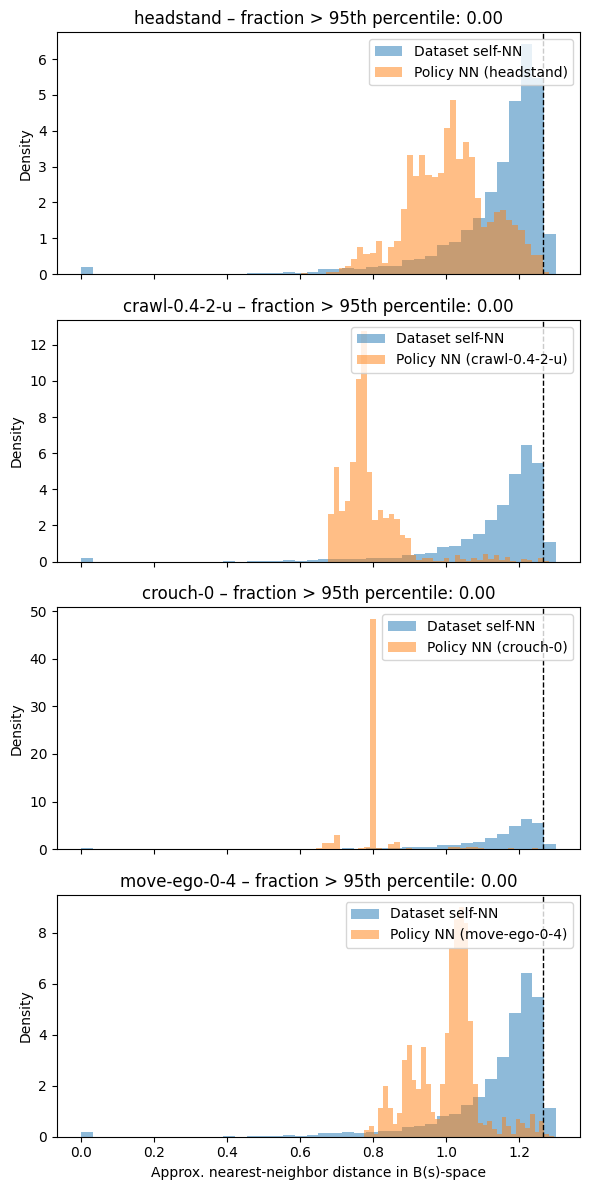

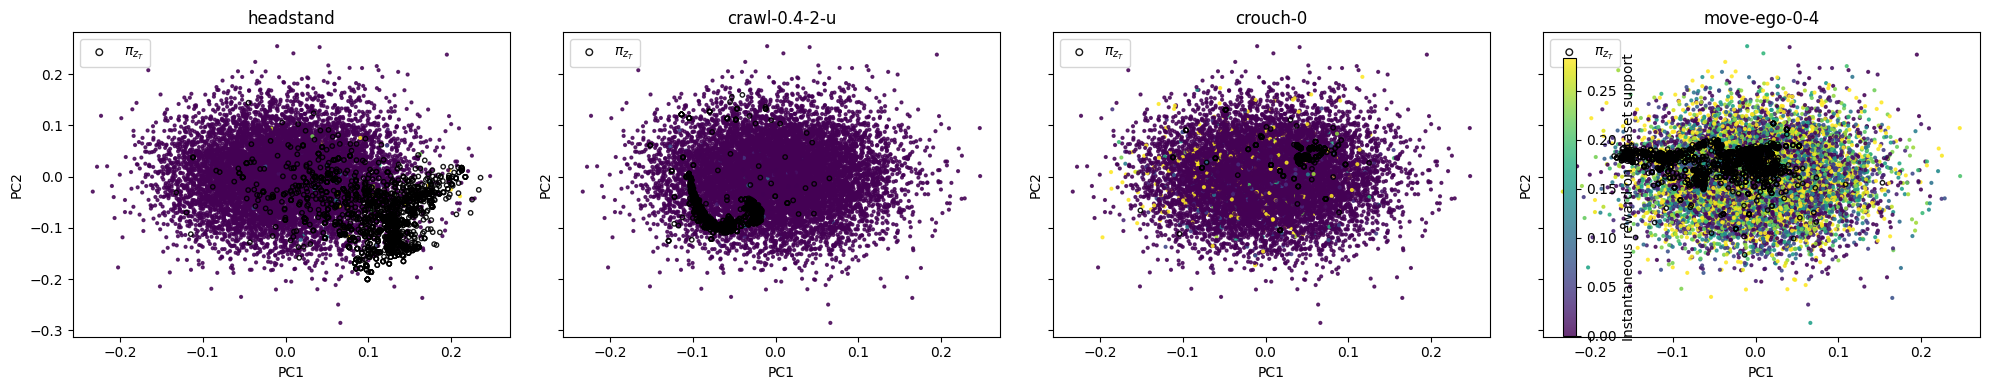

In [10]:
"""
FB-CPR occupancy + reward-colored support experiment on HumEnv.

This script extends the original occupancy experiment by adding a reward-colored
PCA plot of the dataset support in B(s)-space.

For each reward-based HumEnv task T (e.g. headstand, move-ego-0-0):

  1. Sample a large subset of transitions from the Meta Motivo inference buffer.
  2. Compute their backward embeddings B(s) (support cloud).
  3. For *each task T*, compute instantaneous rewards r_T(s,a) for those
     transitions using HumEnv's reward function and the official `relabel`
     utility from Meta Motivo.
  4. Run the zero-shot reward policy π_{z_T} (z_T from RewardWrapper) to get
     its occupancy B_π(s).
  5. Perform a shared 2D PCA on the dataset B(s). For each task T, plot:
       - Dataset points projected in PCA space, colored by r_T (low→high reward).
       - Policy points overlaid as black markers (π_{z_T} trajectory).

This gives a visual answer to: "Where do high-reward states live in the learned
backward basis, and how does the zero-shot latent z_T select an occupancy
relative to that reward landscape?"

We keep the NN-distance histograms from the first experiment unchanged.

Requires:
  - metamotivo[huggingface,humenv]
  - humenv[bench]
  - matplotlib
"""

import os
os.environ["OMP_NUM_THREADS"] = "1"

import math
from pathlib import Path

import h5py
import numpy as np
import torch
import matplotlib.pyplot as plt

from huggingface_hub import hf_hub_download

from metamotivo.fb_cpr.huggingface import FBcprModel
from metamotivo.buffers.buffers import DictBuffer
from metamotivo.wrappers.humenvbench import (
    RewardWrapper,
    relabel,
    get_next,
)

from humenv import make_humenv
import gymnasium

# -------------------------------
# Global configuration
# -------------------------------

MODEL_ID = "facebook/metamotivo-S-1"
DATASET_FILENAME = "buffer_inference_500000.hdf5"
LOCAL_DATA_DIR = "metamotivo-S-1-datasets"

# Number of dataset transitions to use as "support" in B-space
NUM_DATASET_SAMPLES_FOR_EMBEDDINGS = 100_000

# Maximum number of policy states per task to keep for analysis
MAX_POLICY_STATES_PER_TASK = 10_000

# Nearest-neighbor approximation parameters
DATASET_BASELINE_QUERY = 5_000   # dataset self-NN baseline
POLICY_QUERY_PER_TASK = 5_000    # NN distances for each task
NN_CANDIDATES = 512              # candidate neighbors from dataset for approximate NN
NN_BATCH_SIZE = 1024

# Reward relabeling (for dataset rewards) parameters
REWARD_MAX_WORKERS = 16
REWARD_PROCESS_EXECUTOR = False
REWARD_PROCESS_CONTEXT = "spawn"

# Evaluation rollout parameters
NUM_EPISODES_PER_TASK = 20
MAX_EPISODE_STEPS = 300

# Tasks to test
TASKS = [
    "headstand", # FB-CPR LOW
    "crawl-0.4-2-u", # FB-CPR LOW
    "crouch-0", # FB-CPR HIGH
    "move-ego-0-4" # FB-CPR HIGH
]

RANDOM_SEED = 0


# -------------------------------
# Utilities
# -------------------------------

def set_seed(seed: int) -> None:
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


def load_buffer(model_id: str,
                dataset_filename: str,
                local_dir: str):
    """
    Download the Meta Motivo inference buffer from HuggingFace and construct
    both:
      - a DictBuffer (for RewardWrapper)
      - a plain numpy dict `data_np` (for our own indexing and reward relabeling).

    Returns:
        buffer: DictBuffer
        data_np: dict[str, np.ndarray]
    """
    buffer_path = hf_hub_download(
        repo_id=model_id,
        filename=f"data/{dataset_filename}",
        repo_type="model",
        local_dir=local_dir,
    )
    print(f"[INFO] Loaded buffer from: {buffer_path}")

    hf = h5py.File(buffer_path, "r")
    data_np = {k: v[:] for k, v in hf.items()}
    hf.close()

    if "qpos" not in data_np:
        raise KeyError(
            f"'qpos' not found in buffer. Available keys: {list(data_np.keys())}"
        )

    buffer = DictBuffer(capacity=data_np["qpos"].shape[0], device="cpu")
    buffer.extend(data_np)
    print(f"[INFO] DictBuffer created with {len(buffer)} transitions.")

    if "observation" not in data_np:
        raise KeyError(
            f"'observation' not found in buffer. Available keys: {list(data_np.keys())}"
        )

    return buffer, data_np


def build_models(device: torch.device, buffer: DictBuffer):
    """
    Load FB-CPR model and wrap it with RewardWrapper for reward-based inference.

    Returns:
        base_model: FBcprModel
        reward_model: RewardWrapper
    """
    base_model = FBcprModel.from_pretrained(MODEL_ID, device=device)
    base_model.eval()
    print("[INFO] Loaded FB-CPR model from HuggingFace.")

    reward_model = RewardWrapper(
        model=base_model,
        inference_dataset=buffer,
        num_samples_per_inference=100_000,
        inference_function="reward_wr_inference",
        max_workers=REWARD_MAX_WORKERS,
    )
    print("[INFO] Constructed RewardWrapper for reward-based task inference.")

    return base_model, reward_model


def prepare_dataset_support(base_model: FBcprModel,
                            data_np: dict,
                            num_samples: int,
                            device: torch.device,
                            batch_size: int = 4096,
                            seed: int = 0):
    """
    Sample a subset of transitions from the dataset and compute:

      - B_dataset: backward embeddings B(s) of the *observation*,
      - support_data: qpos, qvel, action arrays for those same samples.

    These are then reused across all tasks for:
      - NN distance baselines,
      - reward relabeling per task,
      - PCA support cloud.

    Returns:
        B_dataset: np.ndarray [N, d]
        support_data: dict with keys "qpos", "qvel", "action"
    """
    rng = np.random.default_rng(seed)
    obs_all = data_np["observation"]
    N_total = obs_all.shape[0]
    num_samples = min(num_samples, N_total)

    idx = rng.choice(N_total, size=num_samples, replace=False)
    obs_samples = obs_all[idx]

    # Use the same "next_" convention as RewardWrapper for qpos and qvel
    qpos_all = get_next("qpos", data_np)
    qvel_all = get_next("qvel", data_np)
    action_all = data_np["action"]

    qpos = qpos_all[idx]
    qvel = qvel_all[idx]
    action = action_all[idx]

    print(f"[INFO] Computing backward embeddings for {num_samples} dataset states.")
    all_embeddings = []

    base_model.eval()
    with torch.no_grad():
        for start in range(0, num_samples, batch_size):
            end = min(start + batch_size, num_samples)
            batch = obs_samples[start:end]
            obs_t = torch.from_numpy(batch).to(device=device, dtype=torch.float32)
            emb = base_model.backward_map(obs_t)  # [B, d]
            emb = torch.nn.functional.normalize(emb, dim=-1)
            all_embeddings.append(emb.cpu())

    B_dataset = torch.cat(all_embeddings, dim=0).numpy().astype(np.float32)
    support_data = {
        "qpos": qpos.astype(np.float32),
        "qvel": qvel.astype(np.float32),
        "action": action.astype(np.float32),
    }
    print(f"[INFO] B_dataset shape: {B_dataset.shape}")
    return B_dataset, support_data


def compute_dataset_rewards_per_task(support_data: dict,
                                     tasks: list[str]):
    """
    For each reward-based HumEnv task T, compute instantaneous rewards r_T(s,a)
    on the sampled dataset support transitions using the official `relabel`
    helper from Meta Motivo.

    Returns:
        rewards_per_task: dict[str -> np.ndarray [N]]
            All arrays share the same length N (the size of B_dataset/support_data).
    """
    rewards_per_task: dict[str, np.ndarray] = {}

    qpos = support_data["qpos"]
    qvel = support_data["qvel"]
    action = support_data["action"]
    N = qpos.shape[0]

    for task in tasks:
        print(f"[INFO] Relabeling dataset rewards for task '{task}' on {N} samples ...")
        env, _ = make_humenv(task=task)  # reward fn is env.unwrapped.task

        rewards = relabel(
            env=env,
            qpos=qpos,
            qvel=qvel,
            action=action,
            reward_fn=env.unwrapped.task,
            max_workers=REWARD_MAX_WORKERS,
            process_executor=REWARD_PROCESS_EXECUTOR,
            process_context=REWARD_PROCESS_CONTEXT,
        )
        env.close()

        rewards = rewards.squeeze(-1).astype(np.float32)  # [N, 1] -> [N]
        rewards_per_task[task] = rewards

        print(
            f"[INFO] Task '{task}': dataset reward stats "
            f"min={rewards.min():.2f}, max={rewards.max():.2f}, "
            f"mean={rewards.mean():.2f}"
        )

    return rewards_per_task


def rollout_task(reward_model: RewardWrapper,
                 base_model: FBcprModel,
                 task_name: str,
                 device: torch.device,
                 num_episodes: int,
                 max_episode_steps: int,
                 max_states_for_analysis: int):
    """
    Roll out the reward-based policy π_{z_T} for a given HumEnv task T and
    collect backward embeddings B(s) for visited states.

    Returns:
        B_policy: np.ndarray [N_policy_states, d]
        episode_returns: np.ndarray [num_episodes]
    """
    print(f"[INFO] Starting rollouts for task '{task_name}'.")

    # Infer latent z_T for this task using RewardWrapper
    z = reward_model.reward_inference(task_name)
    if isinstance(z, torch.Tensor):
        z_t = z.to(device=device, dtype=torch.float32)
    else:
        z_t = torch.tensor(z, device=device, dtype=torch.float32)
    if z_t.ndim == 1:
        z_t = z_t.unsqueeze(0)  # [1, dz]

    # Env for policy rollout with flattened observations
    env, _ = make_humenv(
        num_envs=1,
        task=task_name,
        state_init="DefaultAndFall",
        wrappers=[gymnasium.wrappers.FlattenObservation],
    )

    all_B = []
    episode_returns = []
    total_states_collected = 0

    base_model.eval()

    for ep in range(num_episodes):
        obs_np, info = env.reset()
        done = False
        t = 0
        ep_return = 0.0

        while (not done) and (t < max_episode_steps):
            # Prepare obs for both backward_map (torch) and act (RewardWrapper expects np)
            obs_batch_np = obs_np.reshape(1, -1).astype(np.float32)

            # backward embedding of current state
            obs_t = torch.from_numpy(obs_batch_np).to(
                device=device, dtype=torch.float32
            )
            with torch.no_grad():
                B_t = base_model.backward_map(obs_t)  # [1, d]
                B_t = torch.nn.functional.normalize(B_t, dim=-1)
            all_B.append(B_t.cpu().numpy())
            total_states_collected += 1

            # act with zero-shot reward policy (RewardWrapper.act returns numpy)
            action_batch = reward_model.act(obs=obs_batch_np, z=z_t, mean=True)
            action_np = np.asarray(action_batch, dtype=np.float32).reshape(-1)

            obs_np, r, terminated, truncated, info = env.step(action_np)
            ep_return += float(r)
            done = bool(terminated or truncated)
            t += 1

            if total_states_collected >= max_states_for_analysis:
                break

        episode_returns.append(ep_return)
        if total_states_collected >= max_states_for_analysis:
            break

    env.close()
    B_policy = np.concatenate(all_B, axis=0).astype(np.float32)
    episode_returns = np.array(episode_returns, dtype=np.float32)

    print(
        f"[INFO] Task '{task_name}': collected {B_policy.shape[0]} states over "
        f"{len(episode_returns)} episodes. Mean return = {episode_returns.mean():.2f}"
    )

    return B_policy, episode_returns


def approximate_nn_distances(B_dataset: np.ndarray,
                             B_query: np.ndarray,
                             num_candidates: int = NN_CANDIDATES,
                             batch_size: int = NN_BATCH_SIZE,
                             seed: int = 0):
    """
    Approximate nearest-neighbor distances in B-space from query points to the dataset.

    We:
      * randomly choose `num_candidates` dataset points as candidate neighbors,
      * for each query batch, compute Euclidean distances to the candidate set,
      * take the minimum over candidates.
    """
    rng = np.random.default_rng(seed)
    N, d = B_dataset.shape
    M = B_query.shape[0]

    K = min(num_candidates, N)
    candidate_idx = rng.choice(N, size=K, replace=False)
    C = B_dataset[candidate_idx].astype(np.float32)  # [K, d]

    dists = np.empty(M, dtype=np.float32)

    for start in range(0, M, batch_size):
        end = min(start + batch_size, M)
        Q = B_query[start:end].astype(np.float32)  # [B, d]
        diff = Q[:, None, :] - C[None, :, :]       # [B, K, d]
        dist_sq = np.sum(diff * diff, axis=-1)     # [B, K]
        dists[start:end] = np.sqrt(np.min(dist_sq, axis=1))

    return dists


def pca_projection(B_dataset: np.ndarray,
                   B_policies: dict,
                   max_dataset_points: int = 10_000,
                   max_policy_points: int = 2_000,
                   seed: int = 0):
    """
    Compute a 2D PCA of B_dataset and project both dataset and each policy's B(s)
    into that 2D space.

    Returns:
        proj_dataset: np.ndarray [N_ds_sub, 2]
        proj_policies: dict[str -> np.ndarray [N_pol_sub, 2]]
        idx_ds: np.ndarray [N_ds_sub]
            Indices into B_dataset corresponding to proj_dataset rows.
    """
    rng = np.random.default_rng(seed)
    N, d = B_dataset.shape
    N_ds_sub = min(max_dataset_points, N)
    idx_ds = rng.choice(N, size=N_ds_sub, replace=False)
    X_ds = torch.from_numpy(B_dataset[idx_ds]).float()  # [N_ds_sub, d]

    # Center the dataset
    mean = X_ds.mean(dim=0, keepdim=True)  # [1, d]
    X_centered = X_ds - mean

    # Low-rank PCA (Torch >= 2.0)
    U, S, V = torch.pca_lowrank(X_centered, q=2, center=False)  # V: [d, 2]
    V2 = V[:, :2]  # [d, 2]

    proj_dataset = (X_centered @ V2).cpu().numpy()  # [N_ds_sub, 2]

    proj_policies = {}
    for task_name, B_pol in B_policies.items():
        M = B_pol.shape[0]
        if M == 0:
            proj_policies[task_name] = np.zeros((0, 2), dtype=np.float32)
            continue
        M_sub = min(max_policy_points, M)
        idx_pol = rng.choice(M, size=M_sub, replace=False)
        X_pol = torch.from_numpy(B_pol[idx_pol]).float()  # [M_sub, d]
        X_pol_centered = X_pol - mean  # center with dataset mean
        proj_pol = (X_pol_centered @ V2).cpu().numpy()  # [M_sub, 2]
        proj_policies[task_name] = proj_pol

    return proj_dataset, proj_policies, idx_ds


def plot_nn_histograms(dataset_nn: np.ndarray,
                       policy_nns: dict,
                       save_path: str):
    """
    Plot histograms of approximate NN distances:
       - dataset self-NN baseline
       - each task's policy vs dataset
    """
    threshold_95 = np.quantile(dataset_nn, 0.95)
    print(f"[INFO] Dataset 95th percentile NN distance: {threshold_95:.4f}")

    num_tasks = len(policy_nns)
    fig, axes = plt.subplots(
        num_tasks, 1, figsize=(6, 3 * num_tasks), sharex=True
    )

    if num_tasks == 1:
        axes = [axes]

    for ax, (task, dists_pol) in zip(axes, policy_nns.items()):
        ax.hist(
            dataset_nn,
            bins=40,
            density=True,
            alpha=0.5,
            label="Dataset self-NN",
        )
        ax.hist(
            dists_pol,
            bins=40,
            density=True,
            alpha=0.5,
            label=f"Policy NN ({task})",
        )
        frac_ood = float((dists_pol > threshold_95).mean())
        ax.axvline(threshold_95, color="k", linestyle="--", linewidth=1.0)
        ax.set_ylabel("Density")
        ax.set_title(
            f"{task} – fraction > 95th percentile: {frac_ood:.2f}"
        )
        ax.legend(loc="upper right")

    axes[-1].set_xlabel("Approx. nearest-neighbor distance in B(s)-space")

    fig.tight_layout()
    fig.savefig(save_path, dpi=300)
    print(f"[INFO] Saved NN histogram figure to: {save_path}")


def plot_pca_scatter_with_rewards(proj_dataset: np.ndarray,
                                  idx_ds: np.ndarray,
                                  dataset_rewards_per_task: dict,
                                  proj_policies: dict,
                                  save_path: str):
    """
    Plot 2D PCA of dataset backward embeddings and overlay policy occupancies
    for each task. Dataset points are colored by instantaneous reward r_T(s,a)
    for the corresponding task.

    All tasks share the same PCA basis (proj_dataset) and a shared color scale.
    """
    tasks = list(proj_policies.keys())
    num_tasks = len(tasks)

    # Collect rewards only for points used in PCA (idx_ds) to set a robust color scale
    all_colors = []
    for task in tasks:
        rewards = dataset_rewards_per_task[task]
        assert rewards.shape[0] >= idx_ds.max() + 1, \
            "Rewards array length must match B_dataset size."
        all_colors.append(rewards[idx_ds])
    all_colors = np.concatenate(all_colors, axis=0)

    # Use a robust range (5th–95th percentile) to avoid extreme outliers dominating the colorbar
    vmin = float(np.percentile(all_colors, 5.0))
    vmax = float(np.percentile(all_colors, 95.0))
    if math.isclose(vmin, vmax):
        vmin = float(all_colors.min())
        vmax = float(all_colors.max())

    fig, axes = plt.subplots(
        1, num_tasks, figsize=(5 * num_tasks, 4), sharex=True, sharey=True
    )

    if num_tasks == 1:
        axes = [axes]

    # Keep a handle to the last scatter for colorbar
    last_scatter = None

    for ax, task in zip(axes, tasks):
        rewards_ds = dataset_rewards_per_task[task][idx_ds]  # [N_ds_sub]

        sc = ax.scatter(
            proj_dataset[:, 0],
            proj_dataset[:, 1],
            c=rewards_ds,
            s=4,
            alpha=0.8,
            vmin=vmin,
            vmax=vmax,
        )
        last_scatter = sc

        proj_pol = proj_policies[task]
        if proj_pol.shape[0] > 0:
            ax.scatter(
                proj_pol[:, 0],
                proj_pol[:, 1],
                s=10,
                alpha=0.9,
                edgecolor="k",
                facecolor="none",
                label=r"$\pi_{z_T}$",
            )

        ax.set_title(task)
        ax.set_xlabel("PC1")
        ax.set_ylabel("PC2")
        ax.legend(loc="best", markerscale=1.5)

    # Shared colorbar across all subplots
    if last_scatter is not None:
        cbar = fig.colorbar(last_scatter, ax=axes, shrink=0.9)
        cbar.set_label("Instantaneous reward on dataset support")

    fig.tight_layout()
    fig.savefig(save_path, dpi=300)
    print(f"[INFO] Saved PCA reward-colored figure to: {save_path}")


# -------------------------------
# Main entry point
# -------------------------------

def main():
    set_seed(RANDOM_SEED)
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"[INFO] Using device: {device}")

    # 1) Load dataset buffer and raw numpy arrays
    buffer, data_np = load_buffer(MODEL_ID, DATASET_FILENAME, LOCAL_DATA_DIR)

    # 2) Load FB-CPR and RewardWrapper
    base_model, reward_model = build_models(device, buffer)

    # 3) Prepare dataset support: B_dataset and qpos/qvel/action subset
    B_dataset, support_data = prepare_dataset_support(
        base_model=base_model,
        data_np=data_np,
        num_samples=NUM_DATASET_SAMPLES_FOR_EMBEDDINGS,
        device=device,
        seed=RANDOM_SEED,
    )

    # 4) Compute dataset rewards for each task on the same support set
    dataset_rewards_per_task = compute_dataset_rewards_per_task(
        support_data=support_data,
        tasks=TASKS,
    )

    # 5) Roll out policies for each task and collect B(s) for π_{z_T}
    B_policies = {}
    returns_per_task = {}
    for task in TASKS:
        B_pol, ep_returns = rollout_task(
            reward_model=reward_model,
            base_model=base_model,
            task_name=task,
            device=device,
            num_episodes=NUM_EPISODES_PER_TASK,
            max_episode_steps=MAX_EPISODE_STEPS,
            max_states_for_analysis=MAX_POLICY_STATES_PER_TASK,
        )
        B_policies[task] = B_pol
        returns_per_task[task] = ep_returns

    # 6) Approximate NN distance baseline for dataset "self-NN"
    rng = np.random.default_rng(RANDOM_SEED)
    N_ds = B_dataset.shape[0]
    N_query_ds = min(DATASET_BASELINE_QUERY, N_ds)
    idx_query_ds = rng.choice(N_ds, size=N_query_ds, replace=False)
    B_query_ds = B_dataset[idx_query_ds]
    dataset_nn = approximate_nn_distances(
        B_dataset=B_dataset,
        B_query=B_query_ds,
        num_candidates=NN_CANDIDATES,
        batch_size=NN_BATCH_SIZE,
        seed=RANDOM_SEED,
    )
    print(
        f"[INFO] Dataset self-NN distances: mean={dataset_nn.mean():.4f}, "
        f"median={np.median(dataset_nn):.4f}"
    )

    # 7) Approximate NN distances for each policy's occupancy
    policy_nn_dists = {}
    for task, B_pol in B_policies.items():
        M = B_pol.shape[0]
        if M == 0:
            policy_nn_dists[task] = np.zeros(0, dtype=np.float32)
            continue
        N_query_pol = min(POLICY_QUERY_PER_TASK, M)
        idx_pol = rng.choice(M, size=N_query_pol, replace=False)
        B_query_pol = B_pol[idx_pol]
        dists_pol = approximate_nn_distances(
            B_dataset=B_dataset,
            B_query=B_query_pol,
            num_candidates=NN_CANDIDATES,
            batch_size=NN_BATCH_SIZE,
            seed=RANDOM_SEED + 1,
        )
        policy_nn_dists[task] = dists_pol
        print(
            f"[INFO] Task '{task}': NN distances mean={dists_pol.mean():.4f}, "
            f"median={np.median(dists_pol):.4f}"
        )

    # 8) Plot NN histograms
    plot_nn_histograms(
        dataset_nn=dataset_nn,
        policy_nns=policy_nn_dists,
        save_path="fb_humenv_nn_histograms.png",
    )

    # 9) PCA projection and reward-colored scatter plots in B-space
    proj_dataset, proj_policies, idx_ds = pca_projection(
        B_dataset=B_dataset,
        B_policies=B_policies,
        seed=RANDOM_SEED,
    )
    plot_pca_scatter_with_rewards(
        proj_dataset=proj_dataset,
        idx_ds=idx_ds,
        dataset_rewards_per_task=dataset_rewards_per_task,
        proj_policies=proj_policies,
        save_path="fb_humenv_pca_reward_colored.png",
    )

    # 10) Print returns per task for convenience
    print("\n[RESULTS] Episode returns (mean ± std):")
    for task, ep_returns in returns_per_task.items():
        mean_r = ep_returns.mean()
        std_r = ep_returns.std()
        print(f"  {task:20s}: {mean_r:8.2f} ± {std_r:6.2f}")


if __name__ == "__main__":
    main()
